# Loading Packages

In [2]:
cwd_t = "/n/home12/saydjari/finksage/Working/2025_03_25"
cd(cwd_t)
julia_env = "/n/home12/saydjari/finksage/julia_env/harvard_1p11p3"
import Pkg; Pkg.activate(julia_env)

using LinearAlgebra
# File Handling
using Glob, FITSIO, Serialization, HDF5, DelimitedFiles, LibGit2, Suppressor, JLD2, CSV
# Stats
using StatsBase, Distributions, FreqTables, LsqFit, DataStructures, Optim
using BinnedStatistics, KrylovKit, ImageTransformations
import FastRunningMedian: running_median
# Computing
using DataFrames, ProgressMeter, Distributed, BenchmarkTools, ImageFiltering
using Random, Interpolations, SparseArrays, EllipsisNotation, ShiftedArrays
# Astro
using Healpix, SkyCoords, WCS, AstroTime, DustExtinction
# String Formatting
using LaTeXStrings
# Plotting
using CairoMakie; set_theme!(theme_black()); CairoMakie.disable_mime!("svg", "pdf", "text/html");
using ColorSchemes, Printf

  Activating project at `~/finksage/julia_env/harvard_1p11p3`


# Some Rotational Calculations

In [3]:
function isnanorzero(x)
    return isnan(x) | iszero(x)
end

nanzeromean(x) =
    if all(isnanorzero, x)
        NaN
    else
        mean(filter(!isnanorzero, x))
    end
nanzeromean(x, y) = mapslices(nanzeromean, x, dims = y)

nansum(x) = sum(filter(!isnan, x))
nansum(x, y) = mapslices(nansum, x, dims = y)

nanzerosum(x) =
    if all(isnanorzero, x)
        NaN
    else
        sum(filter(!isnanorzero, x))
    end
nanzerosum(x, y) = mapslices(nanzerosum, x, dims = y)

nanzeromedian(x) =
    if all(isnanorzero, x)
        NaN
    else
        median(filter(!isnanorzero, x))
    end
nanzeromedian(x, y) = mapslices(nanzeromedian, x, dims = y)

#@Kevin can we remove?
nanmedian(x) =
    if all(isnan, x)
        NaN
    else
        median(filter(!isnan, x))
    end
nanmedian(x, y) = mapslices(nanmedian, x, dims = y)

"Returns 1 for unit normal"
nanzeroiqr(x) =
    if all(isnanorzero, x)
        NaN
    else
        iqr(filter(!isnanorzero, x)) / 1.34896
    end
nanzeroiqr(x, y) = mapslices(nanzeroiqr, x, dims = y)


nanzeroiqr (generic function with 2 methods)

In [4]:
using Unitful
import PhysicalConstants.CODATA2022: c_0, k_B, h

[ Info: Precompiling MeasurementsSpecialFunctionsExt [4e7bbfdf-6151-5523-96ab-16f816c5a3ee] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling MeasurementsMakieExt [255515a4-532d-589b-944b-ec83cf1d0fb0] (cache misses: wrong dep version loaded (4))
[ Info: Precompiling RootsForwardDiffExt [a63bd285-541a-50a0-818b-605bb84ce7b2] (cache misses: wrong dep version loaded (2), incompatible header (2))


In [13]:
5323.934u"MHz"/c_0 * (10^6)u"Hz"/(1u"MHz") * 1u"m"/(100u"cm") #approx benzene rotational constant (B)

0.17758732276046785 Hz s cm^-1

In [5]:
function P_J(J; B_kT=1e-2)
    return (2*J+1)*B_kT*exp(-J*(J+1)*B_kT)
end

function E_J(J;E_B=1)
    return E_B*J*(J+1)
end

function J_max(B_kT)
    return sqrt(1/(2*B_kT))-1/2
end

J_max (generic function with 1 method)

In [54]:
T = 20u"K" #K
B = 0.002 #cm^-1
E_B = ((B * 10^2)u"1/m" * h * c_0)
B_kT = E_B/(k_B * T);

In [68]:
# Jvec = 0:(1/100):1000
Jvec = 0:1:1000
Evec = E_J.(Jvec,E_B=1)
Pvec = P_J.(Jvec,B_kT=B_kT);
Rb = Evec[2:end-1].-Evec[1:end-2]
Pb = Evec[2:end-1].-Evec[3:end];

w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
datvec = vcat(Rb, Pb)

fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)

(0.785381828835251, 166.76047719496304)

In [69]:
wave_range=4000:1:17_000 #Angstroms
center_wave = 1 ./(wave_range) * 10^8 #cm^(-1)
up_lim = center_wave.+fwhm_tst/2
lw_lim = center_wave.-fwhm_tst/2
up_lim_lambda = 1 ./up_lim * 10^(8)
lw_lim_lambda = 1 ./lw_lim * 10^(8)
dlam = lw_lim_lambda .- up_lim_lambda
dlam[11274]

1.8320172304738662

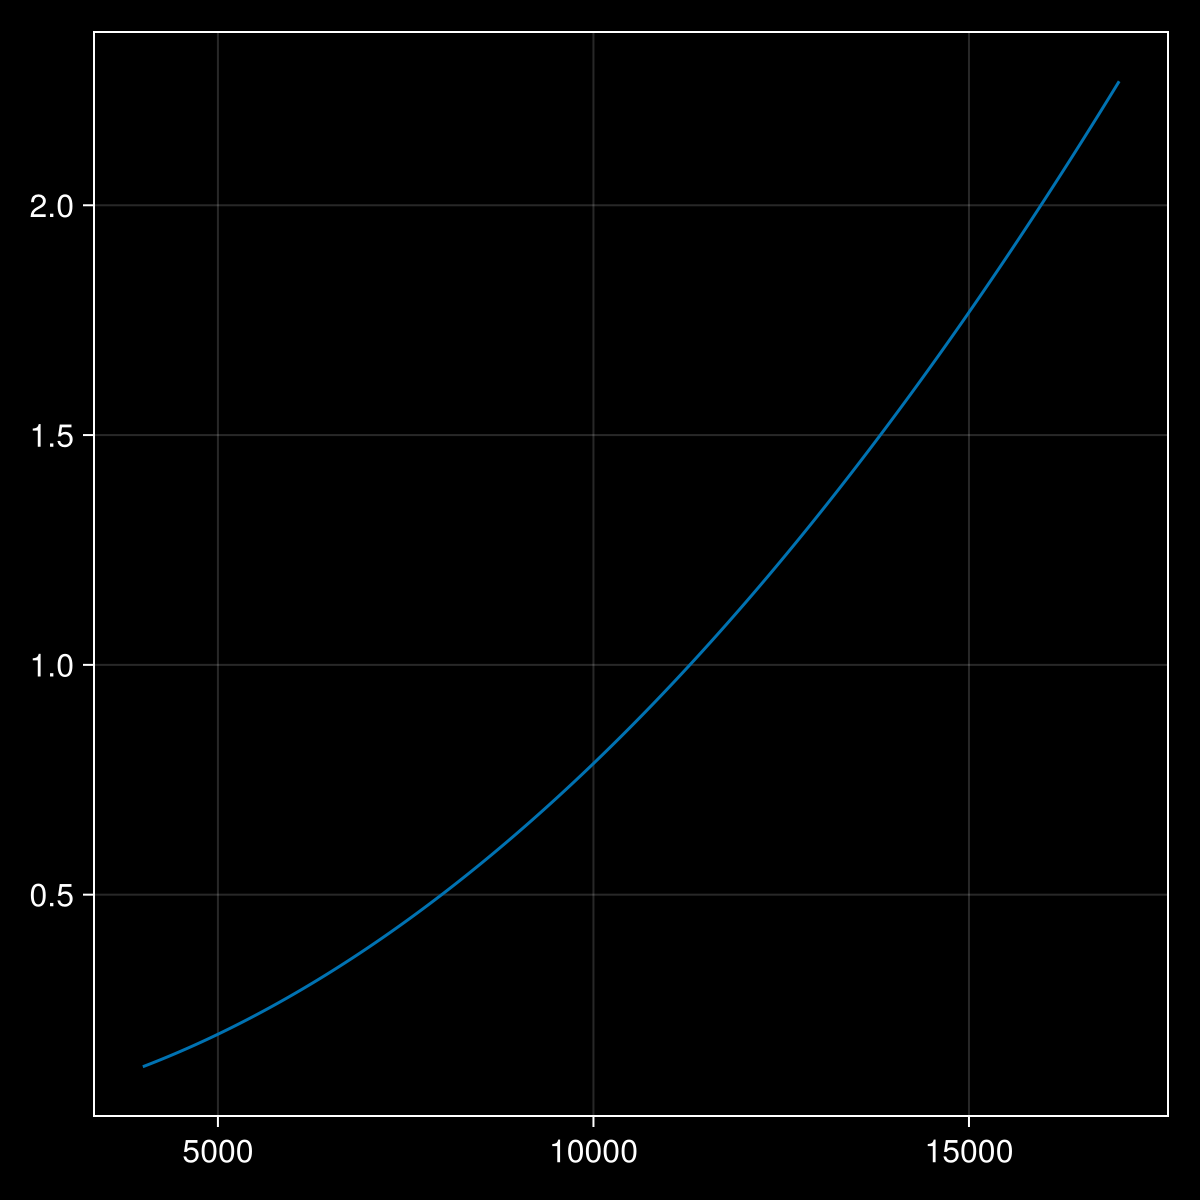

CairoMakie.Screen{IMAGE}


In [70]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    # xlabel="ℓ",
    # ylabel="$(band_lst[i]) mag"
)
lines!(ax,wave_range,dlam)

resize_to_layout!(fig)
display(fig)

In [64]:
findmin(abs.(wave_range.-15273))

(0, 11274)

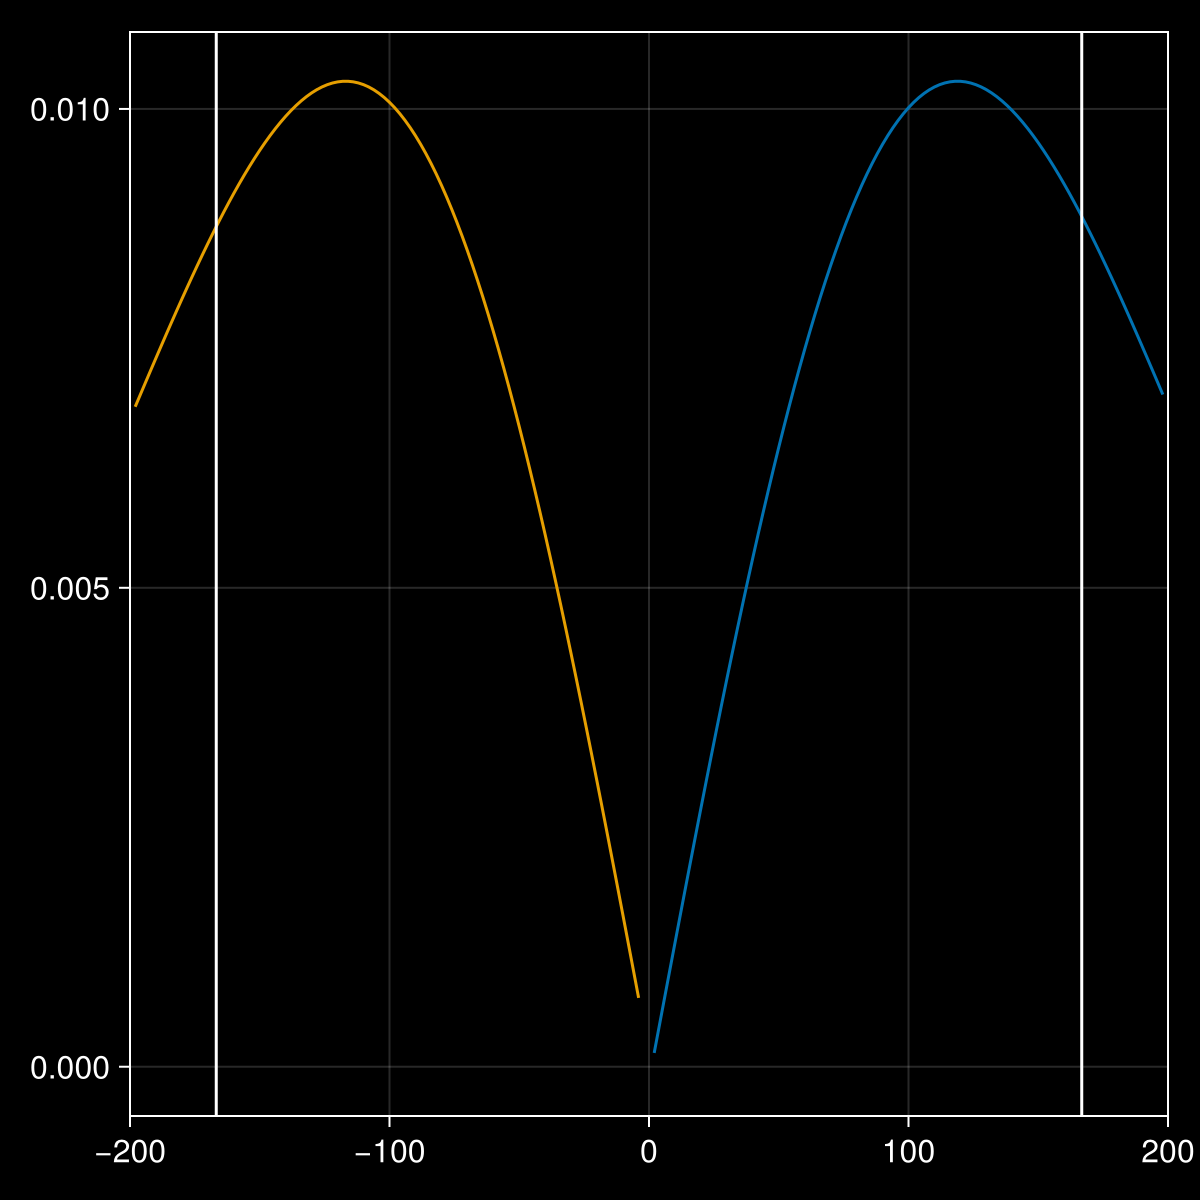

CairoMakie.Screen{IMAGE}


In [67]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    # xlabel="ℓ",
    # ylabel="$(band_lst[i]) mag"
)

lines!(ax,Rb,Pvec[1:end-2])
lines!(ax,Pb,Pvec[3:end])
vlines!(ax,std(datvec,w),color="white")
vlines!(ax,-std(datvec,w),color="white")
xlims!(ax,-200,200)
# xlims!(ax,-5std(datvec,w),5std(datvec,w))

resize_to_layout!(fig)
display(fig)

In [60]:
2*sqrt(2*log(2))*(1/15273*10^10/10^2-1/15274.7*10^10/10^2)

1.715969657985078

In [108]:
1.7u"1/cm"*c_0*(10^2)u"cm"/(1u"m")

5.096471786e10 s^-1

ok, and the problem is that this is the pure rotational spectrum, not the rovibrational spectrum... do I need the product of the occupation probabilities for the upper and lower states... assuming a high overlap integral I guess

except that the vibrational transition is an absorption... so we are really just thinking about transitions out of the ground state and its thermal distribution

In [75]:
Bvec = [0.001, 0.002, 0.005, 0.01]
dlam_mat = zeros(length(center_wave),length(Bvec))
for (indx, B) in enumerate(Bvec)
    E_B = ((B * 10^2)u"1/m" * h * c_0)
    B_kT = E_B/(k_B * T);
    
    Evec = E_J.(Jvec,E_B=1)
    Pvec = P_J.(Jvec,B_kT=B_kT);
    Rb = Evec[2:end-1].-Evec[1:end-2]
    Pb = Evec[2:end-1].-Evec[3:end];

    w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
    datvec = vcat(Rb, Pb)

    fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)
    
    up_lim = center_wave.+fwhm_tst/2
    lw_lim = center_wave.-fwhm_tst/2
    up_lim_lambda = 1 ./up_lim * 10^(8)
    lw_lim_lambda = 1 ./lw_lim * 10^(8)
    dlam = lw_lim_lambda .- up_lim_lambda
    dlam_mat[:,indx].= dlam
end

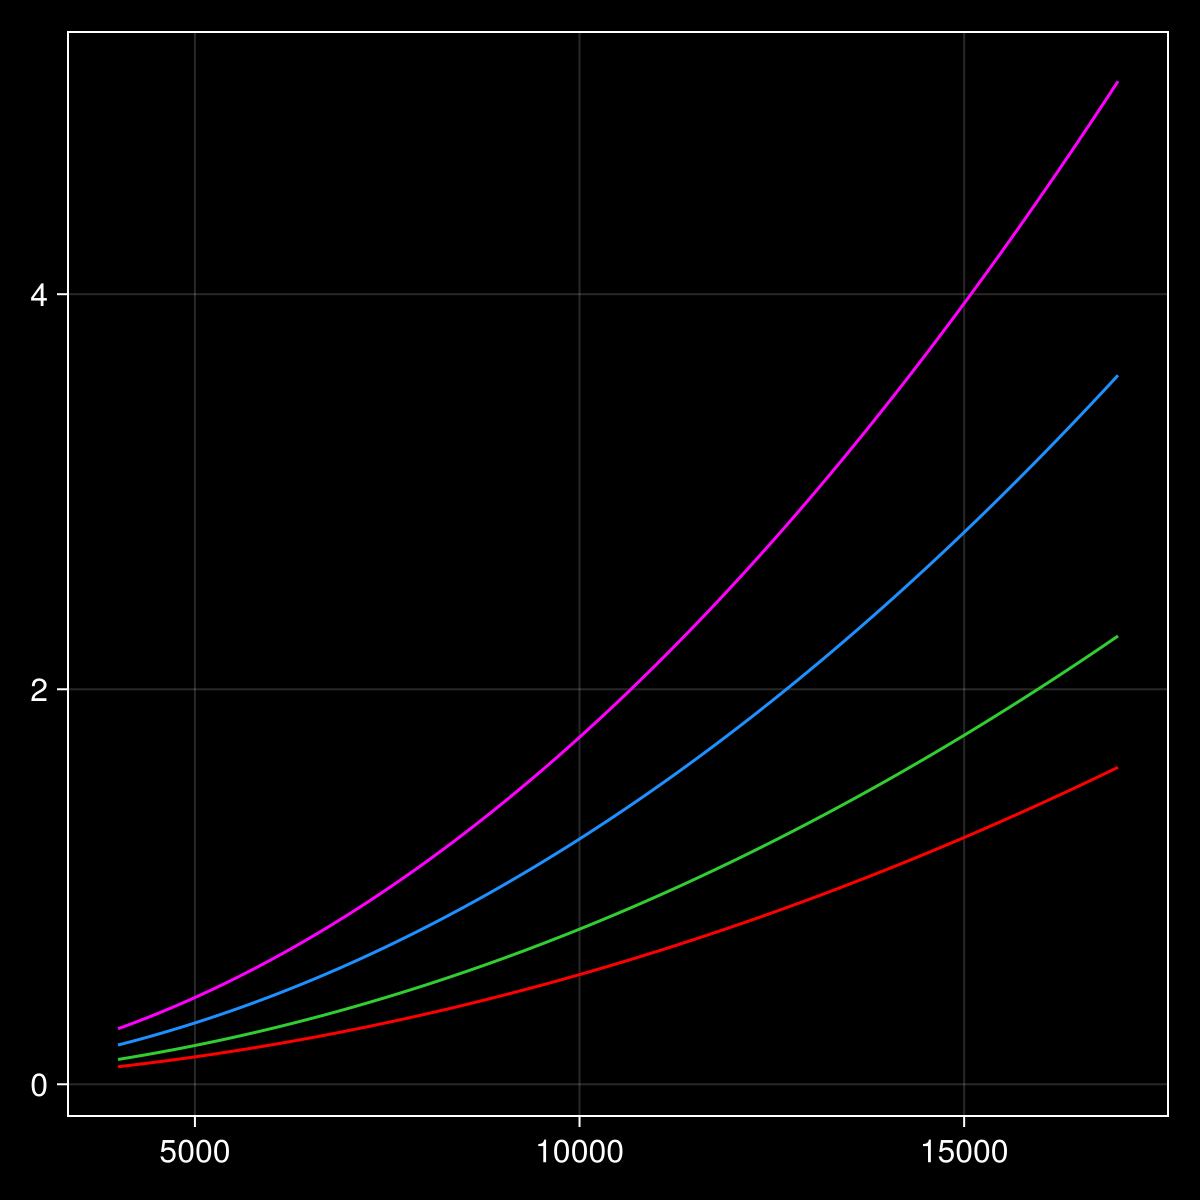

CairoMakie.Screen{IMAGE}


In [76]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    # xlabel="ℓ",
    # ylabel="$(band_lst[i]) mag"
)
color_lst = ["red","limegreen","dodgerblue","magenta","white"]
for indx=1:length(Bvec)
    lines!(ax,wave_range,dlam_mat[:,indx],color=color_lst[indx])
end

resize_to_layout!(fig)
display(fig)

In [78]:
16.857629206/(2/3*60*12*4.5^2) # C60+

0.0017343239923868312

In [89]:
I = 16.857629206/0.002
r0 = (I*(2*1.4^2/12))^(1/4)

7.243823010505239

In [90]:
r0/1.4, (r0/1.4)^2

(5.174159293218028, 26.771924391594485)

In [93]:
r0 = (I/((2/5)*4*12/41.14*4/3*π))^(1/4)

8.103268654547167

In [96]:
(4/3*π*r0^3)/41.14

38.70150141560165

# Temperature Derivative

In [8]:
T = 20u"K" #K
B = 0.002 #cm^-1
E_B = ((B * 10^2)u"1/m" * h * c_0)
B_kT = E_B/(k_B * T);

Jvec = 0:1:1000
Evec = E_J.(Jvec,E_B=1)
Pvec = P_J.(Jvec,B_kT=B_kT);
Rb = Evec[2:end-1].-Evec[1:end-2]
Pb = Evec[2:end-1].-Evec[3:end];

w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
datvec = vcat(Rb, Pb)

Rb0 = copy(Rb)
Pb0 = copy(Pb)
Pvec0 = copy(Pvec);

fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)

(0.785381828835251, 166.76047719496304)

In [9]:
T = 22u"K" #K
B = 0.002 #cm^-1
E_B = ((B * 10^2)u"1/m" * h * c_0)
B_kT = E_B/(k_B * T);

Jvec = 0:1:1000
Evec = E_J.(Jvec,E_B=1)
Pvec = P_J.(Jvec,B_kT=B_kT);
Rb = Evec[2:end-1].-Evec[1:end-2]
Pb = Evec[2:end-1].-Evec[3:end];

w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
datvec = vcat(Rb, Pb)

Rb1 = copy(Rb)
Pb1 = copy(Pb)
Pvec1 = copy(Pvec);

fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)

(0.8237050939151321, 174.89767331760294)

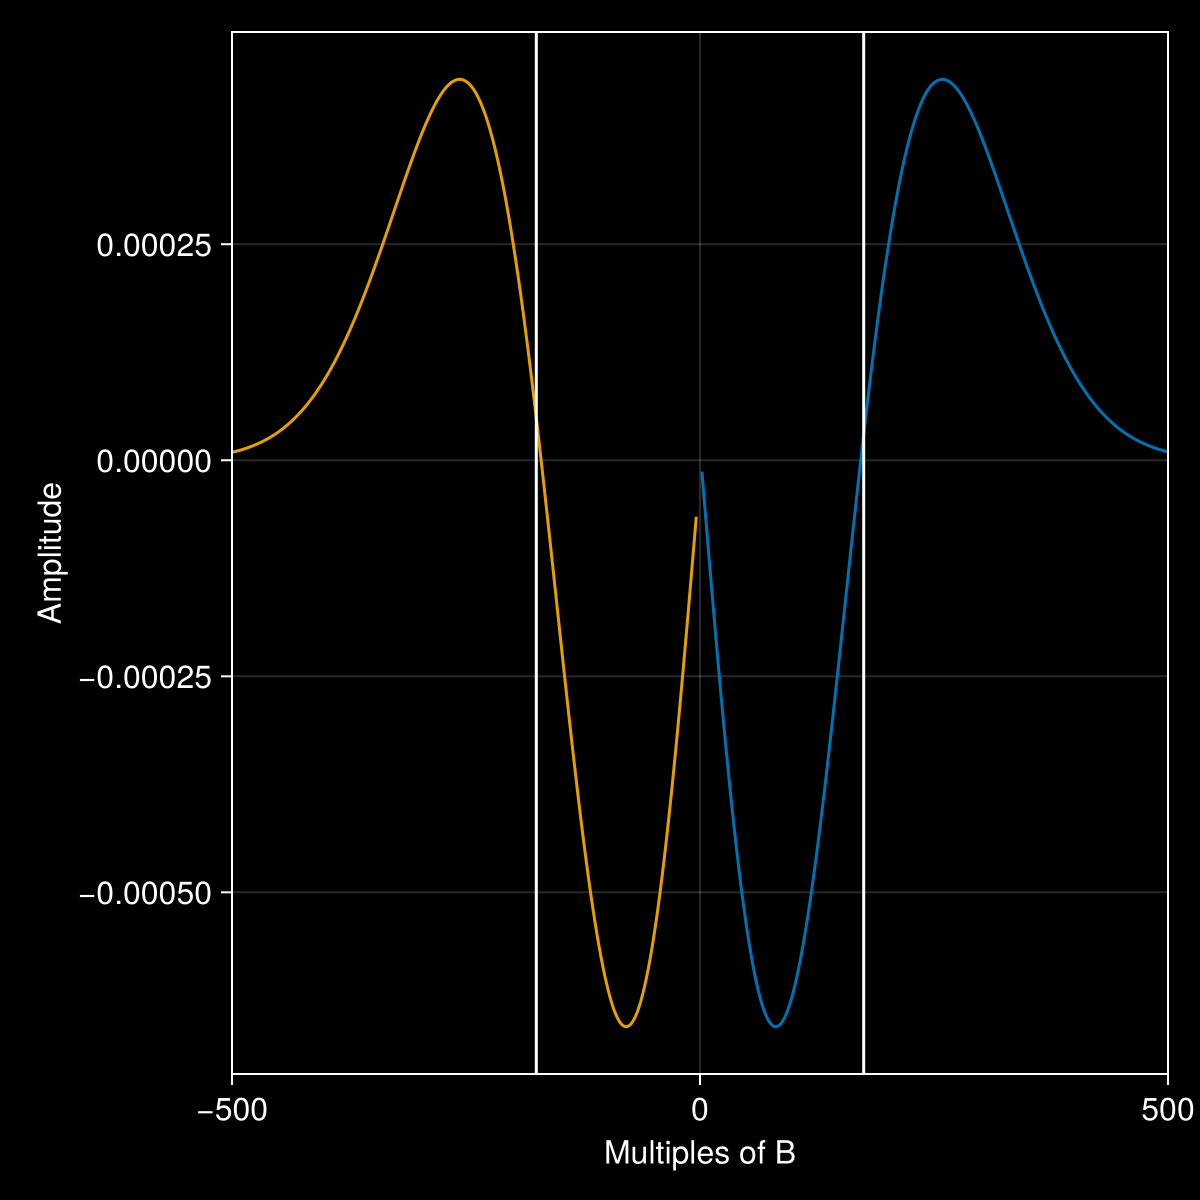

CairoMakie.Screen{IMAGE}


In [10]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    xlabel="Multiples of B",
    ylabel="Amplitude"
)

lines!(ax,Rb,Pvec1[1:end-2].-Pvec0[1:end-2])
lines!(ax,Pb,Pvec1[3:end].-Pvec0[3:end])
vlines!(ax,std(datvec,w),color="white")
vlines!(ax,-std(datvec,w),color="white")
xlims!(ax,-500,500)
# xlims!(ax,-5std(datvec,w),5std(datvec,w))

resize_to_layout!(fig)
display(fig)

In [85]:
function spin_J_GHz(J; B)
    return sqrt(J*(J+1))*2*B*2.99792458e8/(1e-2)/1e9
end

spin_J_GHz (generic function with 1 method)

In [12]:
Jt = J_max(B_kT)

61.32791766405934

In [27]:
sqrt(Jt*(Jt+1))*2*B*2.99792458e8/(1e-2)

7.41397491883647e9

In [70]:
T = 22u"K" #K
B = 0.002 #cm^-1
E_B = ((B * 10^2)u"1/m" * h * c_0)
B_kT = E_B/(k_B * T);

Jvec = 0:1:1000
Evec = E_J.(Jvec,E_B=1)
Pvec = P_J.(Jvec,B_kT=B_kT);
Svec = spin_J_GHz.(Jvec,B=B);
Rb = Evec[2:end-1].-Evec[1:end-2]
Pb = Evec[2:end-1].-Evec[3:end];

w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
datvec = vcat(Rb, Pb)

Rb1 = copy(Rb)
Pb1 = copy(Pb)
Pvec1 = copy(Pvec);

fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)

(0.8237050939151321, 174.89767331760294)

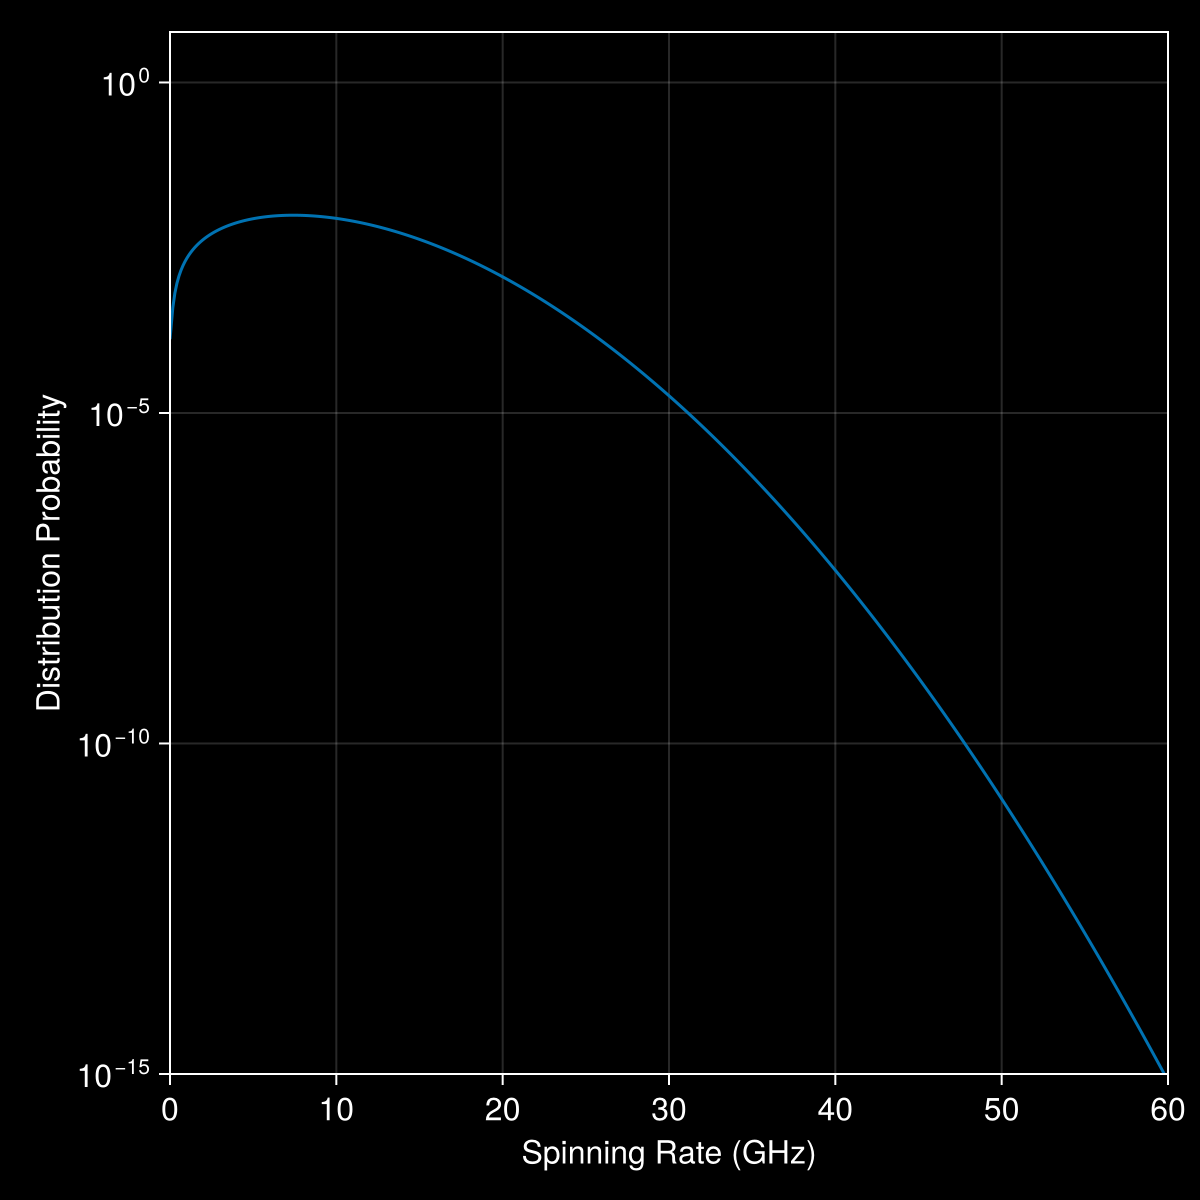

CairoMakie.Screen{IMAGE}


In [110]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    xlabel="Spinning Rate (GHz)",
    ylabel="Distribution Probability",
    yscale=log10
)

lines!(ax,Svec,Pvec)
xlims!(ax,0,60)
ylims!(ax,low=1e-15)
# vlines!(ax,7.5,color="white")

resize_to_layout!(fig)
display(fig)

In [86]:
T = 22u"K" #K
B = 0.002 #cm^-1
E_B = ((B * 10^2)u"1/m" * h * c_0)
B_kT = E_B/(k_B * T);

Jvec = 0:1:1000
Evec = E_J.(Jvec,E_B=1)
Pvec = P_J.(Jvec,B_kT=B_kT);
Svec = spin_J_GHz.(Jvec,B=B);
Rb = Evec[2:end-1].-Evec[1:end-2]
Pb = Evec[2:end-1].-Evec[3:end];

w = FrequencyWeights(vcat(Pvec[1:end-2],Pvec[3:end]))
datvec = vcat(Rb, Pb)

Rb1 = copy(Rb)
Pb1 = copy(Pb)
Pvec1 = copy(Pvec);

fwhm_tst, sig_b = 2*sqrt(2*log(2))*B*std(datvec,w), std(datvec,w)

(0.8237050939151321, 174.89767331760294)

In [87]:
wvec = FrequencyWeights(Pvec)
ν_vec_GHz = Svec;

In [93]:
ν2 = mean(ν_vec_GHz.^2,wvec)

109.93644483294955

In [99]:
function jansky_nu(ν,ν2)
    return ν^6 /(ν2^(3/2)) * exp(-3ν^2/(2*ν2))
end

jansky_nu (generic function with 1 method)

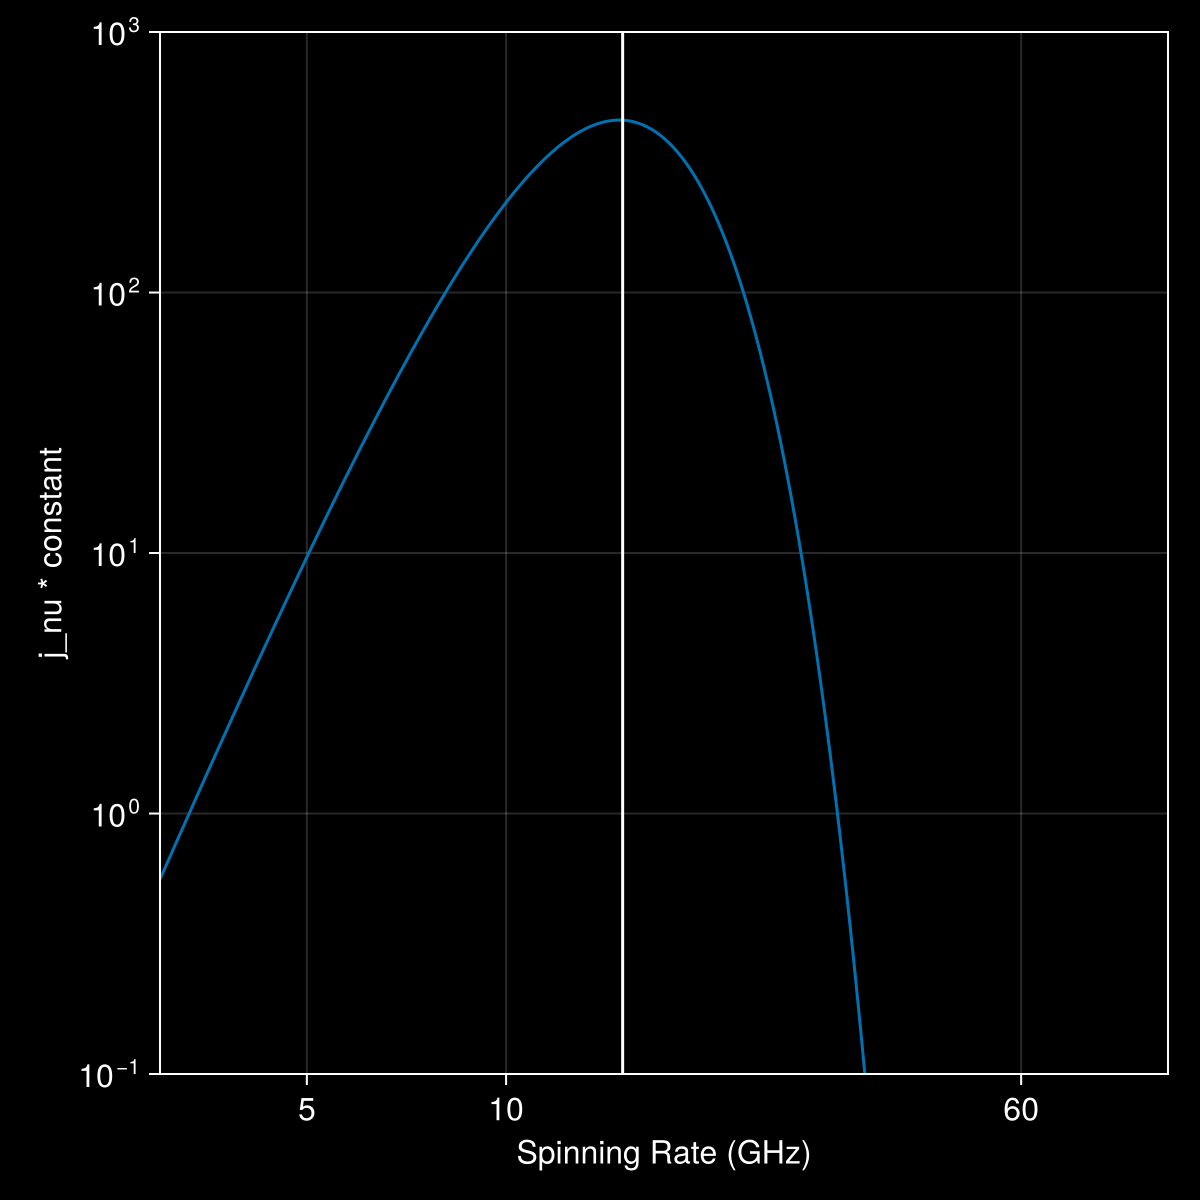

CairoMakie.Screen{IMAGE}


In [111]:
fig = Figure(size=(600,600),fontsize=16)
ax = Axis(fig[1,1],
    xlabel="Spinning Rate (GHz)",
    ylabel="j_nu * constant",
    yscale=log10,
    xscale=log10,
    xticks=[5,10,60]
)

lines!(ax,Svec,jansky_nu.(Svec,Ref(ν2)))
xlims!(ax,3,100)
ylims!(ax,low=1e-1)
vlines!(ax,15,color="white")

resize_to_layout!(fig)
display(fig)

https://iopscience.iop.org/article/10.1086/306387/pdf